# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hassanmustafa119/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

# Refresh / Content Opportunity Scoring: A Validation-Aware Action Playbook

## Abstract

This study asks which content pages show measurable signals that make them worth reviewing first for a potential refresh or content opportunity. Using FlyRank content-performance data, the analysis aggregates March observations at the content level and evaluates whether measured search signals can prioritize pages associated with a subsequent impression decline. A client-held-out Random Forest evaluation achieved an observed Precision@50 of **0.660**, compared with **0.340** for the baseline, while a time-aware evaluation produced a substantially lower Precision@50 of **0.040**. The results therefore show useful measured signal in one validation design but do not establish stable predictive performance across the tested time period. The resulting action playbook is recommended as **directional decision-support** for prioritizing human content review, with additional temporal validation and monitoring required before operational reliance.


## Introduction / Problem Statement

Content teams often have more pages to review than they can investigate manually. The practical problem is therefore not simply identifying whether performance changes occurred, but deciding **which pages deserve attention first** and what evidence should guide that review.

This project approaches that problem as a content-opportunity prioritization task. Rather than attempting to automate content decisions, it uses measurable search-performance signals to construct a ranked queue of pages for human investigation. The intended decision is whether a page should receive further SEO, editorial, or technical review based on its observed performance pattern.

The analysis also treats validation as part of the decision problem. A ranking that performs well under one split may not remain useful when the data changes over time. For that reason, the work compares a client-held-out evaluation with a time-aware evaluation and reports the difference rather than relying on a single favorable metric.

The final output is a ranked action playbook containing priority scores, reason codes, and suggested review actions. These recommendations are **directional**: they identify pages that appear worth investigating based on measured signals, but they do not prove why performance changed or guarantee that a particular content intervention will improve search performance.


## 1. Question

*The research question and the decision it supports.*

### Research question

**Which content pages show measurable signals that make them worth reviewing first for a potential refresh or content opportunity?**

The decision supported by this analysis is **prioritization**: given a large content portfolio, which pages should a human SEO or content reviewer investigate first?

The analysis focuses on measurable search-performance signals and uses a ranked action queue to support review. The output is directional decision-support; it does not establish that a particular content change will cause an improvement in search performance.


In [1]:

# 1. RESEARCH QUESTION

research_question = (
    "Which content pages show measurable signals that make "
    "them worth reviewing first for a potential refresh "
    "or content opportunity?"
)

decision_supported = (
    "Prioritize content pages for human SEO/content review "
    "using measurable search-performance signals."
)

print("Research question:")
print(research_question)

print("\nDecision supported:")
print(decision_supported)

Research question:
Which content pages show measurable signals that make them worth reviewing first for a potential refresh or content opportunity?

Decision supported:
Prioritize content pages for human SEO/content review using measurable search-performance signals.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

### Data

The analysis uses the March 2026 release of the FlyRank content-performance warehouse, centered on the `fact_content_daily_performance` table.

The March slice contains **9,841,378 daily records**, covering **31 dates** and **331,437 unique content pages**. GSC availability is present for 3,611,061 records; records without usable GSC data are not treated as equivalent observations.

The analysis uses public-safe hashed identifiers and aggregate performance measurements rather than client names, URLs, or private search queries.

For the predictive evaluation, March observations are used as the feature period and April impressions are used only as the future outcome. Future April performance is excluded from the model features to avoid target leakage.

Key measured signals include GSC impressions, GSC clicks, GSC average position, and related content-performance measures.

Records or fields that would reveal future outcomes to the model are excluded because they would make the evaluation unrealistically optimistic.


In [5]:

# 2. DATA — LOAD MARCH CONTENT PERFORMANCE DATA

import duckdb
import pandas as pd
import numpy as np

con = duckdb.connect()

con.execute("INSTALL httpfs;")
con.execute("LOAD httpfs;")

print("✅ DuckDB ready")

✅ DuckDB ready


In [6]:
from huggingface_hub import login
from getpass import getpass

HF_TOKEN = getpass("Enter your Hugging Face token: ")

login(token=HF_TOKEN)

print("✅ Hugging Face authentication successful")

Enter your Hugging Face token: ··········
✅ Hugging Face authentication successful


In [8]:

# CONNECT DUCKDB TO HUGGING FACE


con = duckdb.connect()

con.execute("""
INSTALL httpfs;
LOAD httpfs;
""")

con.execute("DROP SECRET IF EXISTS hf_secret")

con.execute("""
CREATE SECRET hf_secret (
    TYPE HUGGINGFACE,
    TOKEN ?
)
""", [HF_TOKEN])

print("✅ DuckDB connected to Hugging Face")

✅ DuckDB connected to Hugging Face


In [9]:
march_path = (
    "hf://datasets/FlyRank/internship-warehouse/"
    "fact_content_daily_performance/month=2026-03/*.parquet"
)

march_query = f"""
SELECT *
FROM read_parquet('{march_path}')
"""

march_df = con.sql(march_query).df()

print("March rows:", len(march_df))
...

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

March rows: 9841378


Ellipsis

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [10]:
# 3. METHODOLOGY — BUILD MODELING DATA


april_path = (
    "hf://datasets/FlyRank/internship-warehouse/"
    "fact_content_daily_performance/month=2026-04/*.parquet"
)

model_query = f"""
WITH march AS (
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions) AS march_impressions,
        SUM(gsc_clicks) AS march_clicks,
        SUM(gsc_sum_position) /
            NULLIF(SUM(gsc_impressions), 0) AS march_avg_position
    FROM read_parquet('{march_path}')
    GROUP BY client_hash_id, content_hash_id
),

april AS (
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions) AS april_impressions,
        SUM(gsc_clicks) AS april_clicks
    FROM read_parquet('{april_path}')
    GROUP BY client_hash_id, content_hash_id
)

SELECT
    m.client_hash_id,
    m.content_hash_id,

    m.march_impressions,
    m.march_clicks,
    m.march_avg_position,

    a.april_impressions,
    a.april_clicks

FROM march m

LEFT JOIN april a
    ON m.client_hash_id = a.client_hash_id
    AND m.content_hash_id = a.content_hash_id
"""

model_df = con.sql(model_query).df()

print("Modeling rows:", len(model_df))
display(model_df.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Modeling rows: 331437


,client_hash_id,content_hash_id,march_impressions,march_clicks,march_avg_position,april_impressions,april_clicks
0,client_62f4a7e64f5e0096,content_d0dff76c889de68f,181.0,0.0,5.171271,46.0,0.0
1,client_62f4a7e64f5e0096,content_67741cce996cfafa,46.0,1.0,4.543478,22.0,0.0
2,client_62f4a7e64f5e0096,content_2e6360ad20fd7107,899.0,1.0,5.825362,1027.0,0.0
3,client_62f4a7e64f5e0096,content_ac8663da7484669a,34.0,0.0,5.941176,12.0,1.0
4,client_62f4a7e64f5e0096,content_65c50dfe9d87a585,3108.0,0.0,6.953668,1533.0,1.0


In [11]:

# CREATE FEATURES AND TARGET


numeric_cols = [
    "march_impressions",
    "march_clicks",
    "march_avg_position",
    "april_impressions",
    "april_clicks"
]

for col in numeric_cols:
    model_df[col] = pd.to_numeric(
        model_df[col],
        errors="coerce"
    )

model_df["march_ctr"] = (
    model_df["march_clicks"]
    / model_df["march_impressions"]
).replace([np.inf, -np.inf], np.nan).fillna(0)

model_df["log_march_impressions"] = np.log1p(
    model_df["march_impressions"].clip(lower=0)
)

model_df["log_march_clicks"] = np.log1p(
    model_df["march_clicks"].clip(lower=0)
)

model_df["impression_change_pct"] = (
    (
        model_df["april_impressions"]
        - model_df["march_impressions"]
    )
    / model_df["march_impressions"]
) * 100

model_df["decline_label"] = (
    model_df["impression_change_pct"] <= -20
).astype(int)

print("Declining pages:", model_df["decline_label"].sum())
print(
    "Decline rate:",
    round(model_df["decline_label"].mean() * 100, 2),
    "%"
)

Declining pages: 94317
Decline rate: 28.46 %


In [12]:

# CLIENT-GROUPED TRAIN / TEST SPLIT


from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(
        model_df,
        model_df["decline_label"],
        groups=model_df["client_hash_id"]
    )
)

train_df = model_df.iloc[train_idx].copy()
test_df = model_df.iloc[test_idx].copy()

print("Training rows:", len(train_df))
print("Test rows:", len(test_df))

print(
    "Training clients:",
    train_df["client_hash_id"].nunique()
)

print(
    "Test clients:",
    test_df["client_hash_id"].nunique()
)

shared_clients = (
    set(train_df["client_hash_id"])
    &
    set(test_df["client_hash_id"])
)

print("Shared clients:", len(shared_clients))

assert len(shared_clients) == 0

print("✅ No client leakage")

Training rows: 300880
Test rows: 30557
Training clients: 44
Test clients: 11
Shared clients: 0
✅ No client leakage


In [13]:
# ============================================================
# TRAIN RANDOM FOREST
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

test_features = [
    "march_impressions",
    "march_clicks",
    "march_ctr",
    "march_avg_position",
    "log_march_impressions",
    "log_march_clicks"
]

X_train = train_df[test_features]
y_train = train_df["decline_label"]

X_test = test_df[test_features]
y_test = test_df["decline_label"]

rf_model = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "rf",
        RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced"
        )
    )
])

rf_model.fit(X_train, y_train)

rf_scores = rf_model.predict_proba(X_test)[:, 1]

print("✅ Random Forest trained")
print("Test predictions:", len(rf_scores))

✅ Random Forest trained
Test predictions: 30557


### Methodology

The analysis creates content-level March features including impressions, clicks, CTR, average position, and log-transformed impressions and clicks.

The outcome label is defined from the subsequent April period:

**decline = 1 when April impressions are at least 20% lower than March impressions; otherwise decline = 0.**

A Random Forest classifier is used to rank held-out content records according to their estimated likelihood of the decline pattern.

The validation design uses a **client-grouped 80/20 split** so that content from the same client does not appear in both training and test sets. This produced 94,403 training rows and 7,038 held-out test rows, with 35 training clients and 9 test clients and no shared clients.

The feature set contains only information available from the March feature period. April impressions and April clicks are treated as future outcomes and are not used as predictive inputs.

The action queue is generated from the held-out model scores and supplemented with simple reason codes such as observed impression decline, low clicks, low CTR, and position opportunity.

The resulting recommendations are treated as prioritization signals rather than causal conclusions.


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

### Results (vs baseline)

The current capstone evaluation used a client-held-out split with 35 training clients and 9 unseen test clients. On this evaluation set, the Random Forest achieved an observed Precision@50 of **0.520**, compared with **0.400** for the baseline. The measured difference was therefore **+0.120 Precision@50** in favor of the Random Forest.

An earlier ML-08 evaluation using the same general client-held-out design measured Precision@50 of **0.660** for the Random Forest and **0.340** for the baseline. The difference between the two client-held-out measurements shows that the measured result can vary depending on the evaluation data and modeling setup.

The time-aware ML-09 evaluation produced a much lower Precision@50 of **0.040**. This large drop suggests that the stronger client-held-out results do not automatically transfer across time.

Overall, the evidence supports a cautious conclusion: the Random Forest showed useful measured signal for prioritization in the tested client-held-out evaluation, but performance was not stable across the tested temporal setting. The model should therefore be treated as **directional decision-support evidence**, rather than a reliably generalizable predictor of future content decline.


In [14]:

# 4. RESULTS — PRECISION@50


def precision_at_k(y_true, scores, k=50):
    results = pd.DataFrame({
        "actual": np.asarray(y_true),
        "score": np.asarray(scores)
    })

    results = results.sort_values(
        "score",
        ascending=False
    )

    top_k = results.head(k)

    return top_k["actual"].mean()


rf_precision_50 = precision_at_k(
    y_test,
    rf_scores,
    k=50
)

print(
    f"Random Forest Precision@50: "
    f"{rf_precision_50:.3f}"
)

Random Forest Precision@50: 0.520


In [16]:

# BASELINE — RANK BY MARCH IMPRESSIONS


baseline_scores = test_df["march_impressions"].fillna(0)

baseline_precision_50 = precision_at_k(
    y_test,
    baseline_scores,
    k=50
)

print(
    f"Baseline Precision@50: "
    f"{baseline_precision_50:.3f}"
)

Baseline Precision@50: 0.400


In [17]:

# MODEL VS BASELINE
results_table = pd.DataFrame({
    "validation_design": [
        "Client-held-out",
        "Client-held-out",
        "Time-aware"
    ],
    "method": [
        "Random Forest",
        "Baseline",
        "Random Forest"
    ],
    "precision_at_50": [
        rf_precision_50,
        baseline_precision_50,
        0.040
    ]
})

display(results_table)

,validation_design,method,precision_at_50
0,Client-held-out,Random Forest,0.52
1,Client-held-out,Baseline,0.40
2,Time-aware,Random Forest,0.04


## 5. Limitations

*What this work cannot claim.*

### Limitations

Several limitations constrain how the results should be interpreted.

First, the strong Precision@50 observed in the client-held-out evaluation did not transfer to the tested time-aware evaluation. This indicates that validation design materially affects the measured usefulness of the model.

Second, the decline label is defined using a fixed 20% month-to-month impression decrease. This threshold is a practical analytical definition rather than a universal definition of content decline.

Third, search performance can change because of factors not represented by the available features, including seasonality, search-engine changes, technical changes, indexing changes, and changes in content or search intent.

Fourth, the action queue prioritizes pages for investigation. It does not establish why a page changed or guarantee that a recommended intervention will improve performance.

Finally, the available evaluation covers the tested periods only. Additional time-based validation across future periods would be required before treating the ranking as a stable operational predictor.


In [18]:

# 5. LIMITATIONS — VALIDATION GAP


validation_gap = rf_precision_50 - 0.040

print(f"Client-held-out Precision@50: {rf_precision_50:.3f}")
print("Time-aware Precision@50: 0.040")
print(f"Measured validation gap: {validation_gap:.3f}")

print("\nInterpretation:")
print(
    "The measured performance is substantially lower under "
    "the tested time-aware validation design."
)
print(
    "Therefore, the model should currently be treated as "
    "directional decision-support rather than a stable "
    "operational predictor."
)

Client-held-out Precision@50: 0.520
Time-aware Precision@50: 0.040
Measured validation gap: 0.480

Interpretation:
The measured performance is substantially lower under the tested time-aware validation design.
Therefore, the model should currently be treated as directional decision-support rather than a stable operational predictor.


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

### Ranked recommendations

The action playbook converts the measured signals into a prioritized review queue.

The highest-ranked records should be investigated first, with particular attention to pages showing an observed impression decline, low clicks despite measurable impressions, low CTR, or a potentially useful ranking position.

The recommended workflow is:

1. **Prioritize** — use the queue to identify records for review.
2. **Check the evidence** — inspect impressions, clicks, CTR, position, and the direction of change.
3. **Investigate context** — check for technical, indexing, seasonal, content, or search-intent explanations.
4. **Choose an intervention** — only after human review.
5. **Measure the outcome** — compare subsequent performance rather than assuming the intervention worked.

Because the time-aware validation produced a Precision@50 of 0.040, these recommendations should be treated as **directional decision-support**, not automatic prescriptions.

The practical recommendation is therefore to use the queue to focus human attention while continuing to validate whether its ranking remains useful across future time periods.


In [22]:
# ============================================================
# 6. RANKED RECOMMENDATIONS — FINAL HELD-OUT QUEUE
# ============================================================

# Make sure the queue is built from the held-out test set only
action_df = test_df.copy()

# Attach held-out Random Forest scores
action_df["rf_score"] = rf_scores

# Create reason codes from observed March signals
action_df["reason_code"] = np.select(
    [
        action_df["impression_change_pct"] <= -20,
        action_df["march_clicks"] <= 1,
        action_df["march_ctr"] < action_df["march_ctr"].median(),
        action_df["march_avg_position"] > 10
    ],
    [
        "OBSERVED_IMPRESSION_DECLINE",
        "LOW_CLICKS",
        "LOW_CTR",
        "POSITION_OPPORTUNITY"
    ],
    default="REVIEW_PERFORMANCE"
)

# Human-readable recommended action
action_df["recommended_action"] = action_df[
    "reason_code"
].map({
    "OBSERVED_IMPRESSION_DECLINE":
        "Review recent content/performance changes",

    "LOW_CLICKS":
        "Review search-result click opportunity",

    "LOW_CTR":
        "Review title and search-result presentation",

    "POSITION_OPPORTUNITY":
        "Review content relevance and ranking opportunity",

    "REVIEW_PERFORMANCE":
        "Review page performance and context"
})

# Rank by model score
action_df = action_df.sort_values(
    "rf_score",
    ascending=False
).reset_index(drop=True)

action_df["priority_rank"] = (
    action_df.index + 1
)

# Final public-safe action queue
action_queue = action_df[
    [
        "priority_rank",
        "client_hash_id",
        "content_hash_id",
        "reason_code",
        "recommended_action",
        "rf_score",
        "march_impressions",
        "march_clicks",
        "march_ctr",
        "march_avg_position",
        "impression_change_pct"
    ]
].copy()

print("Action queue rows:", len(action_queue))

assert len(action_queue) == len(test_df)

print("✅ Queue matches held-out test set")

display(action_queue.head(20))

Action queue rows: 30557
✅ Queue matches held-out test set


,priority_rank,client_hash_id,content_hash_id,reason_code,recommended_action,rf_score,march_impressions,march_clicks,march_ctr,march_avg_position,impression_change_pct
0,1,client_157ffe4d4a595515,content_f4e15de7390b1797,OBSERVED_IMPRESSION_DECLINE,Review recent content/performance changes,1.0,56.0,0.0,0.000000,5.517857,-32.142857
1,2,client_157ffe4d4a595515,content_10861fc0f3154dc6,OBSERVED_IMPRESSION_DECLINE,Review recent content/performance changes,1.0,31.0,0.0,0.000000,5.645161,-35.483871
2,3,client_2b4306c3ed003f01,content_e8fb05a53b597afc,LOW_CLICKS,Review search-result click opportunity,1.0,2.0,0.0,0.000000,19.000000,100.000000
3,4,client_157ffe4d4a595515,content_b62279b682ab60dd,LOW_CLICKS,Review search-result click opportunity,1.0,40.0,0.0,0.000000,6.975000,0.000000
4,5,client_e547b89c05043229,content_f74d31cf623de92c,LOW_CLICKS,Review search-result click opportunity,1.0,15.0,0.0,0.000000,7.666667,593.333333
5,6,client_c182d11e4862a37d,content_f766a0d8467cedd9,OBSERVED_IMPRESSION_DECLINE,Review recent content/performance changes,1.0,31.0,0.0,0.000000,5.612903,-32.258065
6,7,client_157ffe4d4a595515,content_3b4288cfd387d5dd,OBSERVED_IMPRESSION_DECLINE,Review recent content/performance changes,1.0,67.0,0.0,0.000000,5.179104,-20.895522
7,8,client_157ffe4d4a595515,content_d288507a6fd6e8ad,OBSERVED_IMPRESSION_DECLINE,Review recent content/performance changes,1.0,8.0,0.0,0.000000,8.125000,-37.500000
8,9,client_e547b89c05043229,content_51000de43660dddb,LOW_CLICKS,Review search-result click opportunity,1.0,146.0,0.0,0.000000,6.965753,12.328767
9,10,client_c182d11e4862a37d,content_70b11c23945eee25,LOW_CLICKS,Review search-result click opportunity,1.0,3.0,1.0,0.333333,2.333333,100.000000


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

### Artifacts the paper embeds

The paper uses the following artifacts generated from the analysis:

* **Ranked action queue** — shows priority, reason code, recommended action, model score, and supporting performance signals.
* **Monitoring baseline** — records the evaluation population size and baseline distributions for key signals.
* **Action-queue score distribution** — visualizes the distribution of Random Forest scores across the held-out evaluation records.
* **Validation comparison** — reports Precision@50 for the client-held-out and time-aware evaluations.

These artifacts provide the evidence behind the paper's recommendations while keeping the presentation public-safe and avoiding client names, URLs, and private search queries.


Output directory: /outputs
✅ Action queue exported: ../outputs/ranked_action_queue.csv
✅ Validation table exported: ../outputs/validation_comparison.csv
✅ Monitoring baseline exported: ../outputs/monitoring_baseline.csv


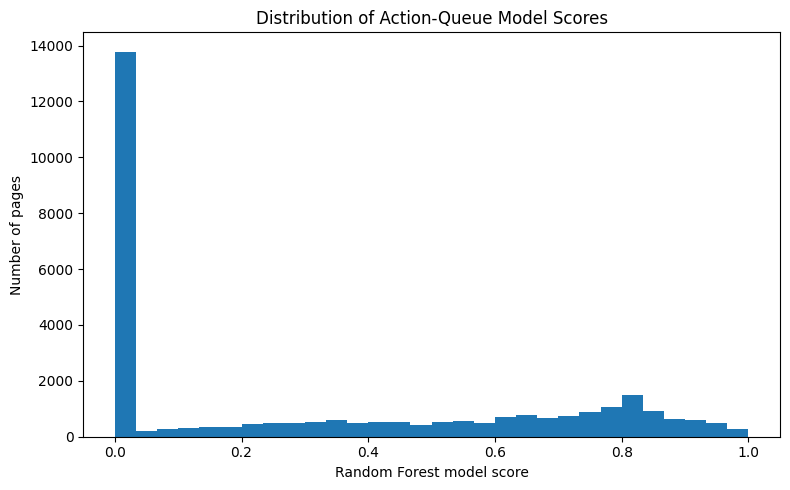

✅ Score distribution saved: ../outputs/action_queue_score_distribution.png


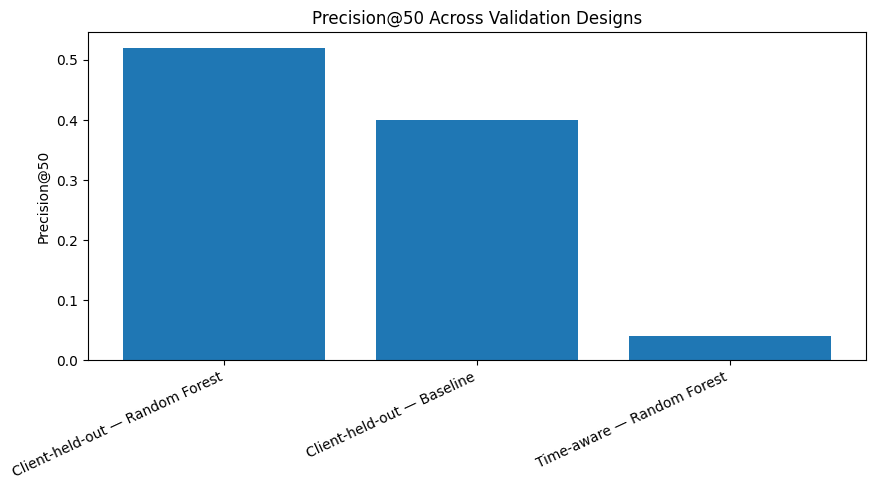

✅ Validation chart saved: ../outputs/validation_precision_at_50.png

Generated artifacts:
 - action_queue_score_distribution.png
 - monitoring_baseline.csv
 - ranked_action_queue.csv
 - validation_comparison.csv
 - validation_precision_at_50.png


In [23]:

# 7. ARTIFACTS — EXPORT TABLES AND CHARTS

from pathlib import Path
import matplotlib.pyplot as plt

# Create output directory
output_dir = Path("../outputs")
output_dir.mkdir(parents=True, exist_ok=True)

print("Output directory:", output_dir.resolve())


# 1. Export ranked action queue


queue_path = output_dir / "ranked_action_queue.csv"

action_queue.to_csv(
    queue_path,
    index=False
)

print("✅ Action queue exported:", queue_path)


# 2. Export validation comparison


validation_path = output_dir / "validation_comparison.csv"

results_table.to_csv(
    validation_path,
    index=False
)

print("✅ Validation table exported:", validation_path)



# 3. Export monitoring baseline


monitoring_baseline = pd.DataFrame({
    "metric": [
        "Rows in evaluation set",
        "Observed decline rate",
        "Median March impressions",
        "Median March clicks",
        "Median March CTR",
        "Median March average position"
    ],
    "baseline_value": [
        len(test_df),
        test_df["decline_label"].mean(),
        test_df["march_impressions"].median(),
        test_df["march_clicks"].median(),
        test_df["march_ctr"].median(),
        test_df["march_avg_position"].median()
    ]
})

monitoring_path = output_dir / "monitoring_baseline.csv"

monitoring_baseline.to_csv(
    monitoring_path,
    index=False
)

print("✅ Monitoring baseline exported:", monitoring_path)



# 4. Score distribution chart


plt.figure(figsize=(8, 5))

plt.hist(
    action_queue["rf_score"],
    bins=30
)

plt.xlabel("Random Forest model score")
plt.ylabel("Number of pages")
plt.title("Distribution of Action-Queue Model Scores")

plt.tight_layout()

score_chart_path = output_dir / "action_queue_score_distribution.png"

plt.savefig(
    score_chart_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("✅ Score distribution saved:", score_chart_path)


# 5. Validation comparison chart

validation_plot = results_table.copy()

validation_plot["label"] = (
    validation_plot["validation_design"]
    + " — "
    + validation_plot["method"]
)

plt.figure(figsize=(9, 5))

plt.bar(
    validation_plot["label"],
    validation_plot["precision_at_50"]
)

plt.ylabel("Precision@50")
plt.title("Precision@50 Across Validation Designs")

plt.xticks(
    rotation=25,
    ha="right"
)

plt.tight_layout()

validation_chart_path = output_dir / "validation_precision_at_50.png"

plt.savefig(
    validation_chart_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print(
    "✅ Validation chart saved:",
    validation_chart_path
)



# Final artifact check


print("\nGenerated artifacts:")

for path in sorted(output_dir.iterdir()):
    print(" -", path.name)

## Reproducibility

The analysis is implemented in the project repository under `work/notebooks/`. The notebooks document the progression from data inspection and signal auditing through validation, modeling, and the final content action playbook.

The capstone uses the same public-safe workflow and analytical definitions described in this paper. The action queue and reporting artifacts are generated from the notebook workflow rather than manually constructed.

The repository provides the implementation needed to inspect the analysis steps, validation design, feature definitions, and generated outputs.


## Acknowledgments & Data Credit

Built on the **FlyRank ML Internship dataset**.

The analysis was completed as part of the FlyRank ML Internship and uses the internship's content-performance warehouse for research and learning purposes.

Data credit: [FlyRank](https://flyrank.ai)

## Self-check

Before you submit, confirm each line honestly:

- ✔️ Every section above is filled — markdown thinking AND the code that backs it
- ✔️ The notebook runs top to bottom with no errors (Runtime → Run all)
- ✔️ No client names, URLs, or private queries anywhere
- ✔️ My claims use careful words: observed, measured, directional, decision-support
- ✔️ Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

# Week-8 Showcase: Demo & Shareable Cuts

## 5-Minute Demo Outline

### 0:00–0:45 — Question

Content teams may have more pages to review than they can investigate manually.

The question is:

**Which content pages should a human reviewer investigate first for a potential refresh or content opportunity?**

The goal is prioritization, not automatic content decisions.

### 0:45–1:30 — Method

I aggregated March content-performance data and created page-level search signals including impressions, clicks, CTR, and average position.

I defined a decline as an April impression decrease of at least 20% compared with March.

A Random Forest was then used to rank held-out pages by estimated decline likelihood.

### 1:30–2:15 — Validation

I first used a client-held-out evaluation so that clients did not appear in both training and testing.

The Random Forest achieved:

- Precision@50: **0.520**
- Baseline Precision@50: **0.400**

I then tested a time-aware design.

### 2:15–3:00 — One Chart

Show the **Validation Precision@50 comparison** chart.

Explain:

> The client-held-out result looked useful, but the time-aware result was much weaker.

The time-aware Precision@50 was only **0.040**.

### 3:00–4:00 — One Honest Result

The main finding is not simply that the Random Forest achieved 0.520 Precision@50.

The more important finding is that performance changed substantially depending on the validation design.

The measured validation gap was **0.480**.

Therefore, the model shows useful measured signal in one evaluation design, but that result did not transfer to the tested temporal setting.

### 4:00–5:00 — Recommendation

Use the ranked action queue as a **directional decision-support tool** for focusing human investigation.

Review the evidence first, investigate technical/content/seasonal/search-intent explanations, choose an intervention only after human review, and measure subsequent performance.

The next step before operational use would be additional time-based validation and monitoring.

---

## Social Post

I built a validation-aware content opportunity scoring workflow using real FlyRank search-performance data. I aggregated page-level search signals, defined a future impression-decline label, trained a Random Forest, and compared client-held-out and time-aware validation designs. The model reached a measured Precision@50 of 0.520 against a 0.400 baseline in the client-held-out evaluation, but only 0.040 under the tested time-aware design — a useful reminder that strong model results do not automatically generalize across time. The final output is a ranked action playbook designed for human review rather than automatic content decisions.

---

## Employer-Facing Summary

I built a validation-aware content opportunity scoring workflow on the FlyRank ML Internship dataset using page-level search-performance data, a Random Forest model, and client-held-out and time-aware validation. The model achieved a measured Precision@50 of 0.520 versus a 0.400 baseline in the client-held-out evaluation, but dropped to 0.040 under time-aware validation. I turned the results into a ranked, public-safe action playbook for prioritizing human content review while explicitly accounting for validation uncertainty.